In [1]:
import numpy as np #importing numpy for numerical operations
import pandas as pd #importing pandas for data manipulation and analysis
import matplotlib.pyplot as plt #importing pyplot for plotting

# Function to read topo file as provided
def readTxt(name):
    df = pd.read_csv(name, header=None, sep="\r")
    topo = []
    for i in range(np.shape(df.values)[0]):
        cc = df.values[i][0].split()
        cc = np.squeeze([float(x) for x in cc])
        topo.append(cc)
    return np.array(topo, dtype=float)

# Function to find fluid points adjacent to windward and leeward faces, considering periodic boundary conditions
def find_fluid_front_and_rear_faces(topo, wind_direction):
    """
    topo: 2D numpy array, with values (obstacle) or 0 (fluid)
    wind_direction: Wind direction vector, e.g., [1, 0] for wind along the x direction
    Returns: Lists of fluid grid points adjacent to windward and leeward faces
    """
    Nx, Ny = topo.shape
    wind_direction = np.array(wind_direction) / np.linalg.norm(wind_direction)  # Normalize wind direction vector

    front_fluid_faces = []  # Fluid grid points adjacent to windward faces
    rear_fluid_faces = []   # Fluid grid points adjacent to leeward faces

    # Iterate over all grid points to find fluid points (value = 0)
    for i in range(Nx):
        for j in range(Ny):
            if topo[i, j] == 0:  # Current point is fluid
                # Check neighbors in four directions, considering periodic boundary conditions
                neighbors = [
                    ((i+1) % Nx, j),  # Positive x direction, to the right (periodic boundary)
                    ((i-1) % Nx, j),  # Negative x direction, to the left (periodic boundary)
                    (i, (j+1) % Ny),  # Positive y direction, upward (periodic boundary)
                    (i, (j-1) % Ny)   # Negative y direction, downward (periodic boundary)
                ]
                is_near_building = False
                for ni, nj in neighbors:
                    if topo[ni, nj] != 0:  # Neighbor is a building, current fluid point is adjacent to a building
                        is_near_building = True
                        break
                if not is_near_building:
                    continue

                # Calculate the direction vector from the fluid point to the building neighbor
                # Determine if the fluid point is on the windward or leeward side
                for ni, nj in neighbors:
                    if topo[ni, nj] != 0:  # Neighbor is a building
                        # Direction vector: from fluid point to building neighbor
                        delta_i = ni - i
                        delta_j = nj - j
                        # Adjust displacement due to periodic boundaries
                        # If delta_i or delta_j is too large, it indicates crossing the periodic boundary, so adjust it
                        if delta_i > Nx // 2:  # If ni wraps around from the left (e.g., i=0, ni=Nx-1)
                            delta_i -= Nx  # Adjust to -1
                        elif delta_i < -Nx // 2:  # If ni wraps around from the right (e.g., i=Nx-1, ni=0)
                            delta_i += Nx  # Adjust to +1
                        if delta_j > Ny // 2:  # If nj wraps around from the bottom
                            delta_j -= Ny
                        elif delta_j < -Ny // 2:  # If nj wraps around from the top
                            delta_j += Ny
                        building_dir = np.array([delta_i, delta_j])
                        # Calculate the angle between wind direction and building direction (dot product)
                        dot_product = np.dot(wind_direction, building_dir)
                        if dot_product > 0:  # Angle between wind direction and building direction < 90 degrees, fluid point is on windward side
                            front_fluid_faces.append((i, j))
                        elif dot_product < 0:  # Angle between wind direction and building direction > 90 degrees, fluid point is on leeward side
                            rear_fluid_faces.append((i, j))
                        break  # Once a building neighbor is found, we can determine the side, so break the loop

    return front_fluid_faces, rear_fluid_faces

# Visualization function
def plot_faces(topo, front_fluid_faces, rear_fluid_faces, wind_direction):
    """
    topo: 2D numpy array, with values (obstacle) or 0 (fluid)
    front_fluid_faces: List of fluid grid points adjacent to windward faces
    rear_fluid_faces: List of fluid grid points adjacent to leeward faces
    wind_direction: Wind direction vector, used to display the wind direction arrow
    """
    Nx, Ny = topo.shape

    # Create a new array for visualization
    # 0: Fluid (white), 1: Building (gray), 2: Fluid adjacent to windward face (red), 3: Fluid adjacent to leeward face (blue)
    vis_array = np.zeros((Nx, Ny))

    # Fill building areas
    vis_array[topo != 0] = 1  # Mark building as 1

    # Mark fluid points adjacent to windward faces
    for i, j in front_fluid_faces:
        vis_array[i, j] = 2  # Mark windward fluid as 2

    # Mark fluid points adjacent to leeward faces
    for i, j in rear_fluid_faces:
        vis_array[i, j] = 3  # Mark leeward fluid as 3

    # Plot the image
    plt.figure(figsize=(8, 8))
    cmap = plt.cm.colors.ListedColormap(['white', 'gray', 'red', 'blue'])  # Custom colors
    plt.imshow(vis_array, cmap=cmap, interpolation='nearest')

    # Add colorbar and set labels
    plt.colorbar(ticks=[0, 1, 2, 3], 
                 label='Region Type',
                 format=plt.FuncFormatter(lambda val, loc: 
                                          {0: 'Fluid', 1: 'Inner building', 2: 'Windward', 3: 'Leeward'}[val]))

    plt.clim(-0.5, 3.5)
    plt.gca().set_xticks(np.arange(0, Ny, 100))
    plt.gca().set_yticks(np.arange(0, Nx, 100))
    plt.gca().set_xticklabels(np.arange(0, Ny, 100))
    plt.gca().set_yticklabels(np.arange(0, Nx, 100))

    # Add wind direction arrow
    wind_direction = np.array(wind_direction) / np.linalg.norm(wind_direction)
    plt.arrow(Ny/2, Nx/2, wind_direction[1]*10, wind_direction[0]*10, 
              head_width=4, head_length=8, fc='red', ec='red', label='Wind direction',width=0.5)

    plt.title('Building and Adjacent Fluid Faces')
    plt.xlabel('Y')
    plt.ylabel('X')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.savefig('test.png',dpi=500)
    #plt.show()

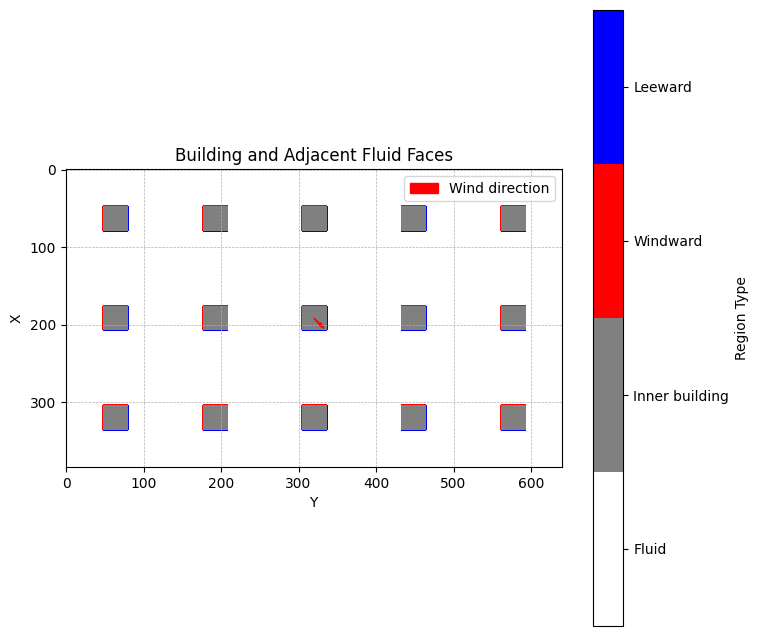

In [2]:
#Defining the path to the topography file (text format) as a string
topo_path = "D:\\Private\\D DRIVE\\FOREIGN UNIVERSITIES\\UNSW\\T1 2025\\BENV7500 Programmable Cities\\Assignment 3\\single topo file\\selected_files_topo\\UA0625_d00\\UA0625_d00_topo"

#read the topography file using the custom function 'readTxt' and store the result in the variable 'topo'
topo = readTxt(topo_path)

#Defining the wind direction as a vector [1,1] to represent a diagonal wind from top-left to bottom-right corner in the plot below (45 degrees)
wind_direction = [1, 1]

#Identifying which faces/cells in the topography are windward (front) and leeward (rear) based on the wind direction
front_faces, rear_faces = find_fluid_front_and_rear_faces(topo, wind_direction)

#Visualizing the topography and highlighting the front (windward) and rear (leeward) faces using a plotting function
plot_faces(topo, front_faces, rear_faces, wind_direction)

In [3]:
#Installing the required libraries)

!pip install xarray netCDF4

#netCDF4 for reading and writing netCDF files (a format used in climate and simulation data)

import xarray as xr #xarray for working with labelled multidimensional arrays (especially for .nc files)
import numpy as np #similarly numpy for working with numericals
import pandas as pd #as well as pandas for data manipulation and analysis

#Defining the file path (as raw string) to the NetCDF file containing the pedestrian-level wind speed data
ped_file_path = r"D:\Private\D DRIVE\FOREIGN UNIVERSITIES\UNSW\T1 2025\BENV7500 Programmable Cities\Assignment 3\single ped file\selected_files_ped\UA0625_d00\UA0625_d00_ped.nc"

#Opening the NetCDF dataset using xarray and store it in the variable 'ds'
ds = xr.open_dataset(ped_file_path)
print(ds)
#printing the dataset summary to inspect its structure, variables, and dimensions

#Now extracting the 'Uped' variable values
Uped = ds['Uped'].values  # First timestep if 3D
x = ds['x'].values #Extract the x coordinate values (horiziontal grid points)
y = ds['y'].values #Extract the y coordinate values (vertical grid points)

<xarray.Dataset> Size: 5MB
Dimensions:  (x: 384, y: 640)
Coordinates:
  * x        (x) float64 3kB 0.0 1.003 2.005 3.008 ... 381.0 382.0 383.0 384.0
  * y        (y) float64 5kB 0.0 1.002 2.003 3.005 ... 637.0 638.0 639.0 640.0
Data variables:
    uped     (x, y) float32 983kB ...
    vped     (x, y) float32 983kB ...
    Uped     (x, y) float32 983kB ...
    TKEped   (x, y) float32 983kB ...
    Tuwped   (x, y) float32 983kB ...


In [4]:
#Creating 2D grid coordinates using matrix indexing ('ij' style for row major order)
X, Y = np.meshgrid(x, y, indexing='ij')
df = pd.DataFrame({
    'x': X.flatten(), #Flatten the 2D X grid into a 1D array for using as a Dataframe Column
    'y': Y.flatten(), #Similarly for the 2D Y grid
    'Uped': Uped.flatten() #Flatten the 2D Uped array to align with coordinates
})
#Combine the flattened coordinate and wind speed data into a pandas Dataframe for easier manipulation and analysis

In [5]:
# Create a 2D label array: 0 = fluid, 1 = windward, 2 = leeward
labels = np.zeros_like(topo)

for i, j in front_faces:
    labels[i, j] = 1
for i, j in rear_faces:
    labels[i, j] = 2

# Add labels to DataFrame using grid indices
label_flat = labels.flatten()
df['label'] = label_flat

# Optional: map label to text
df['label_text'] = df['label'].map({0: 'fluid', 1: 'windward', 2: 'leeward'})

df

,x,y,Uped,label,label_text
0,0.0,0.000000,0.974414,0.0,fluid
1,0.0,1.001565,0.972577,0.0,fluid
2,0.0,2.003130,0.970791,0.0,fluid
3,0.0,3.004695,0.969301,0.0,fluid
4,0.0,4.006260,0.968147,0.0,fluid
...,...,...,...,...,...
245755,384.0,635.993740,0.985048,0.0,fluid
245756,384.0,636.995305,0.982461,0.0,fluid
245757,384.0,637.996870,0.980360,0.0,fluid
245758,384.0,638.998435,0.978616,0.0,fluid


In [6]:
#Filter the dataframe to include only the rows labelled as windward/leeward, and create a copy to avoid with SettingwithCopyWarning
df_filtered = df[df['label_text'].isin(['windward', 'leeward'])].copy()
df_filtered['label_text'].value_counts() #Count and display how many windward and leeward points are present in the filtered dataframe
df_filtered.head() #Display the first five rows of the dataframe for a quick preview

,x,y,Uped,label,label_text
30128,47.122715,48.075117,0.908727,1.0,windward
30129,47.122715,49.076682,0.283542,1.0,windward
30130,47.122715,50.078247,0.105418,1.0,windward
30131,47.122715,51.079812,0.090329,1.0,windward
30132,47.122715,52.081377,0.127800,1.0,windward


In [7]:
#Print the shape (dimensions) of the topography array - shows the grid resolution of the built environment
print("Topography shape:", topo.shape)
#Print the shape of the Uped array - indicates the wind speed data's spatial resolution (as given in coordinates below)
print("Uped shape:", Uped.shape)
#Print the shape of the label's array - confirms that it matches the topography and wind speed grid for proper alignment
print("Labels shape:", labels.shape)

Topography shape: (384, 640)
Uped shape: (384, 640)
Labels shape: (384, 640)


In [8]:
# Rebuild from aligned indices
df = pd.DataFrame({
    'i': np.repeat(np.arange(384), 640), #Create row indices (i) repeated 640 times each (for each x-grid)
    'j': np.tile(np.arange(640), 384), #Create column indices (j) tiled across 384 rows (for each y-grid)
    'Uped': Uped.flatten(), #Flatten the Uped array to align with i,j
    'label': labels.flatten() #Flatten the label array to align with i,j
})

# Map numeric labels to text
df['label_text'] = df['label'].map({0: 'fluid', 1: 'windward', 2: 'leeward'})

#Filter the Dataframe to retain only windward and leeward grid cells and make a copy for further analysis
df_filtered = df[df['label_text'].isin(['windward', 'leeward'])].copy() 

#Calculating the mean Uped (wind speed) for all windward cells, excluding any missing values
mean_windward = df_filtered[df_filtered['label_text'] == 'windward']['Uped'].dropna().mean()

#Calculating the mean Uped (wind speed) for all leeward cells, excluding any missing values
mean_leeward = df_filtered[df_filtered['label_text'] == 'leeward']['Uped'].dropna().mean()

print("Mean wind speed (windward):", mean_windward) #Output the mean windward speed
print("Mean wind speed (leeward):", mean_leeward) #Output the mean leeward wind speed
print("Average wind speed difference (windward - leeward):", mean_windward - mean_leeward) #Output the difference for overall mean wind speed


Mean wind speed (windward): 0.4206658
Mean wind speed (leeward): nan
Average wind speed difference (windward - leeward): nan


In [9]:
# Get grid indices of all leeward points
leeward_indices = df[df['label_text'] == 'leeward'][['i', 'j']].values

# Check a few Uped values at those positions
for idx in leeward_indices[:10]:
    i, j = idx
    print(f"Uped[{i}, {j}] =", Uped[i, j])

Uped[48, 80] = nan
Uped[48, 208] = nan
Uped[48, 336] = nan
Uped[48, 464] = nan
Uped[48, 592] = nan
Uped[49, 80] = nan
Uped[49, 208] = nan
Uped[49, 336] = nan
Uped[49, 464] = nan
Uped[49, 592] = nan


In [10]:
nan_count = 0 #Initialize a counter for NaN values
for i, j in leeward_indices: #Iterate over all leeward grid points
    if np.isnan(Uped[i, j]): #Check if the Uped value is NaN (missing data)
        nan_count += 1 #Increment counter if NaN is found

#Print how many of the total leeward points contain missing wind speed data
print(f"{nan_count} out of {len(leeward_indices)} leeward points have NaN Uped values") #This reassures that the data itself had missing values and nothing went wrong with the calculation in code

960 out of 960 leeward points have NaN Uped values


In [11]:
#Now learning from this hassle. To avoid going through turbulence during calculations because of the presence of NaN values.
#I have made a custom function, where we can look out for the presence of Nan values for any corresponding attribute
#There is a python file named 'nan_checker' in the same directory for this purpose and better hints are given below

from nan_checker import check_nan_by_category

# Check NaNs in 'Uped' column for all categories in 'label_text'
#check_nan_by_category(df, category_column='label_text', value_column='Uped')

# OR: Check only for leeward cases
#check_nan_by_category(df, category_column='label_text', value_column='Uped', target_category='leeward')

check_nan_by_category(df, category_column='label_text', value_column='Uped')

NaN values in 'Uped' for category 'fluid': 15360
NaN values in 'Uped' for category 'leeward': 960
NaN values in 'Uped' for category 'windward': 0


{'fluid': 15360, 'leeward': 960, 'windward': 0}

In [12]:
#Defining the path to the metadata CSV file, Reading it, and Displaying its first 5 rows to preview its structure and contents
metadata_path = "D:\\Private\\D DRIVE\\FOREIGN UNIVERSITIES\\UNSW\\T1 2025\\BENV7500 Programmable Cities\\Assignment 3\\metadata-idealized.csv"
metadata_df= pd.read_csv(metadata_path)
metadata_df.head()

,NameI,NameE,Config,WD,dxdy,City,State,Country,Longitude,Latitude,...,lp,lf,gammaH,gamma,hmean,hstd,hmax,hmin,H/h,SAR
0,A0625,UA0625_d00,idealized-uniform_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.062500,0.062500,31.4531,0.7876,16.0,0.0,16.0,16.0,8.0,A
1,A1111,UA1111_d00,idealized-uniform_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.111111,0.111111,21.2917,0.7112,16.0,0.0,16.0,16.0,8.0,A
2,A1600,UA16_d00,idealized-uniform_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.160000,0.160000,16.1625,0.6481,16.0,0.0,16.0,16.0,8.0,A
3,A2500,UA25_d00,idealized-uniform_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.250000,0.250000,10.9688,0.5502,16.0,0.0,16.0,16.0,8.0,A
4,A3500,UA35_d00,idealized-uniform_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.351166,0.351166,7.6644,0.4559,16.0,0.0,16.0,16.0,8.0,A


In [13]:
import pandas as pd #Import pandas for data manipulation; re-import ensures this cell is self-contained if run in isolation
import numpy as np #Import NumPy for numerical operations; re-import guarantees availability regardless of previous cells
import xarray as xr #Import xarray for working with NetCDF (.c) datasets; re-import makes this cell standalone
import os #Import os for file and path operations

# Your base folder path, here we took files with prevailing wind in 0 degree direction only due to large amount of files. Later, ones with 45 degrees are to undergo the same process separately
base_path = "D:\\Private\\D DRIVE\\FOREIGN UNIVERSITIES\\UNSW\\T1 2025\\BENV7500 Programmable Cities\\Assignment 3\\WD 0\\selected_files"

# Load metadata
metadata = pd.read_csv('metadata-idealized.csv')  # Make sure this CSV is in your notebook folder or give full path

# Function to convert wind direction (degrees) to unit vector
def deg_to_vector(deg):
    rad = np.deg2rad(deg) #Convert degrees to radians
    return [np.cos(rad), np.sin(rad)] #Return the unit vector [x-component, y-component]

# Initialize list to store results
results = []

#Loop through each row in metadata where wind direction WD == 0
for idx, row in metadata[metadata['WD'] == 0].iterrows():
    name = row['NameE'] #Case name identifier
    wind_dir_deg = row['WD'] #Wind direction in degrees (here always 0)
    wind_vector = [1, 1]  # Normalized inside the function anyway
    
    #Construct file paths for this case's topo and ped files
    topo_path = os.path.join(base_path, name, f"{name}_topo")
    ped_path = os.path.join(base_path, name, f"{name}_ped.nc")

    try:
        # Load topo
        topo = readTxt(topo_path)

        # Identifying windward (front) and leeward (rear) faces in the topo grid
        front_faces, rear_faces = find_fluid_front_and_rear_faces(topo, wind_vector)

        # Assign labels
        labels = np.zeros_like(topo)
        for i, j in front_faces:
            labels[i, j] = 1 #Marking windward faces
        for i, j in rear_faces:
            labels[i, j] = 2 #Marking leeward faces

        # Load pedestrian level wind speed data from the NetCDF
        ds = xr.open_dataset(ped_path)
        Uped = ds['Uped'].values  # Extract the Uped variable as NumPy array - Assumes 2D

        # Flatten into DataFrame
        df = pd.DataFrame({
            'i': np.repeat(np.arange(topo.shape[0]), topo.shape[1]),
            'j': np.tile(np.arange(topo.shape[1]), topo.shape[0]),
            'Uped': Uped.flatten(), #wind speed at each cell
            'label': labels.flatten() #numeric value at each cell
        })
        df['label_text'] = df['label'].map({0: 'fluid', 1: 'windward', 2: 'leeward'}) #Mapping numeric labels to descriptive text

        # Computing mean wind speeds in windward and leeward zones
        mean_windward = df[df['label_text'] == 'windward']['Uped'].dropna().mean()
        mean_leeward = df[df['label_text'] == 'leeward']['Uped'].dropna().mean()
        diff = mean_windward - mean_leeward if pd.notna(mean_leeward) else np.nan #Difference between windward and leeward for overall mean, or NaN if any data is missing

        # Store result
        results.append({
            'NameE': name,
            'Uped_windward': mean_windward,
            'Uped_leeward': mean_leeward,
            'Uped_diff': diff
        })

    except Exception as e:
        print(f"❌ Error processing {name}: {e}") #Handling errors (e.g., missing files or others) by logging and appending NaNs
        results.append({
            'NameE': name,
            'Uped_windward': np.nan,
            'Uped_leeward': np.nan,
            'Uped_diff': np.nan
        })

# After looping, merge the Uped results back into the metadata Dataframe
results_df = pd.DataFrame(results)
metadata_updated = metadata.merge(results_df, on='NameE', how='left')
metadata_updated.to_csv('metadata_with_uped_WD0.csv', index=False)

#Save the merged metadata with wind speed statistics (ones with prevailing wind direction is 0 degrees) into a new CSV
print("✅ Processing complete. File saved as 'metadata_with_uped_WD0.csv'")


✅ Processing complete. File saved as 'metadata_with_uped_WD0.csv'


In [14]:
metadata_updated.head(20) #Here we preview the newly merged metadata

,NameI,NameE,Config,WD,dxdy,City,State,Country,Longitude,Latitude,...,gamma,hmean,hstd,hmax,hmin,H/h,SAR,Uped_windward,Uped_leeward,Uped_diff
0,A0625,UA0625_d00,idealized-uniform_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.7876,16.0,0.000000,16.0,16.0,8.0,A,0.420666,NaN,NaN
1,A1111,UA1111_d00,idealized-uniform_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.7112,16.0,0.000000,16.0,16.0,8.0,A,0.344705,NaN,NaN
2,A1600,UA16_d00,idealized-uniform_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.6481,16.0,0.000000,16.0,16.0,8.0,A,0.314318,NaN,NaN
3,A2500,UA25_d00,idealized-uniform_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.5502,16.0,0.000000,16.0,16.0,8.0,A,0.269930,NaN,NaN
4,A3500,UA35_d00,idealized-uniform_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.4559,16.0,0.000000,16.0,16.0,8.0,A,0.213904,NaN,NaN
5,A4444,UA4444_d00,idealized-uniform_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.3780,16.0,0.000000,16.0,16.0,8.0,A,0.203621,NaN,NaN
6,A5300,UA53_d00,idealized-uniform_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.3126,16.0,0.000000,16.0,16.0,8.0,A,0.185087,0.584517,-0.399430
7,A6400,UA64_d00,idealized-uniform_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.2322,16.0,0.000000,16.0,16.0,8.0,A,0.343137,NaN,NaN
8,VA0625std28,VA0625-SM-28_d00,idealized-CL_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.7876,16.0,2.828427,20.0,12.0,8.0,A,0.596795,0.573317,0.023478
9,VA1111std28,VA1111-SM-28_d00,idealized-CL_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.7112,16.0,2.828427,20.0,12.0,8.0,A,0.424614,0.512574,-0.087961


In [15]:
# Keep only rows where windward and leeward values exist
valid_data = metadata_updated.dropna(subset=['Uped_windward', 'Uped_leeward', 'Uped_diff'])

# Saving this to a new CSV
valid_data.to_csv('metadata_uped_valid_only.csv', index=False)

valid_data #Here we preview the updated merged metadata

,NameI,NameE,Config,WD,dxdy,City,State,Country,Longitude,Latitude,...,gamma,hmean,hstd,hmax,hmin,H/h,SAR,Uped_windward,Uped_leeward,Uped_diff
6,A5300,UA53_d00,idealized-uniform_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.3126,16.0,0.000000,16.0,16.0,8.0,A,0.185087,0.584517,-0.399430
8,VA0625std28,VA0625-SM-28_d00,idealized-CL_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.7876,16.0,2.828427,20.0,12.0,8.0,A,0.596795,0.573317,0.023478
9,VA1111std28,VA1111-SM-28_d00,idealized-CL_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.7112,16.0,2.828427,20.0,12.0,8.0,A,0.424614,0.512574,-0.087961
10,VA16std28,VA16-SM-28_d00,idealized-CL_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.6481,16.0,2.828427,20.0,12.0,8.0,A,0.322943,0.467271,-0.144328
11,VA25std28,VA25-SM-28_d00,idealized-CL_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.5502,16.0,2.828427,20.0,12.0,8.0,A,0.245904,0.303106,-0.057203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,VS253356,VS25-CL-56_d00,idealized-SM_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.2507,16.0,5.773503,26.0,6.0,8.0,S,0.338297,0.237082,0.101215
108,VS353356,VS35-CL-56_d00,idealized-SM_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.2043,16.0,5.773503,26.0,6.0,8.0,S,0.279930,0.253788,0.026141
109,VS44443356,VS4444-CL-56_d00,idealized-SM_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.1672,16.0,5.773503,26.0,6.0,8.0,S,0.257599,0.271093,-0.013495
110,VS533356,VS53-CL-56_d00,idealized-SM_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.1369,16.0,5.773503,26.0,6.0,8.0,S,0.249509,0.309988,-0.060479


In [16]:
#As mentioned earlier, due to size/quantitiy of the files, only the ones with prevailing wind direction as 0 degrees are included in earlier process.
#Now we repeat the entire same process for the ones with prevailing wind direction as 45 degrees

import pandas as pd
import numpy as np
import xarray as xr
import os

# Base path for WD = 45 files
base_path = r"D:\Private\D DRIVE\FOREIGN UNIVERSITIES\UNSW\T1 2025\BENV7500 Programmable Cities\Assignment 3\WD 45\selected_files"

# Load the same metadata file again
metadata = pd.read_csv('metadata-idealized.csv')  # Point to be noted - Ensure same CSV used for consistency

# Use fixed wind direction vector [1, 1]
wind_vector = [1, 1]

# Container for results
results_45 = []

for idx, row in metadata[metadata['WD'] == 45].iterrows():
    name = row['NameE']
    topo_path = os.path.join(base_path, name, f"{name}_topo")
    ped_path = os.path.join(base_path, name, f"{name}_ped.nc")

    try:
        # Load topo
        topo = readTxt(topo_path)

        # Identifying windward (front) and leeward (rear) faces in the topo grid
        front_faces, rear_faces = find_fluid_front_and_rear_faces(topo, wind_vector)

        # Label fluid points
        labels = np.zeros_like(topo)
        for i, j in front_faces:
            labels[i, j] = 1 #Marking windward faces
        for i, j in rear_faces:
            labels[i, j] = 2 #Marking leeward faces

        # Load pedestrian level wind speed data from the NetCDF
        ds = xr.open_dataset(ped_path)
        Uped = ds['Uped'].values

        # Build DataFrame
        df = pd.DataFrame({
            'i': np.repeat(np.arange(topo.shape[0]), topo.shape[1]),
            'j': np.tile(np.arange(topo.shape[1]), topo.shape[0]),
            'Uped': Uped.flatten(),
            'label': labels.flatten()
        })
        df['label_text'] = df['label'].map({0: 'fluid', 1: 'windward', 2: 'leeward'})

        # Computing mean wind speeds in windward and leeward zones
        mean_windward = df[df['label_text'] == 'windward']['Uped'].dropna().mean()
        mean_leeward = df[df['label_text'] == 'leeward']['Uped'].dropna().mean()
        diff = mean_windward - mean_leeward if pd.notna(mean_leeward) and pd.notna(mean_windward) else np.nan #Difference between windward and leeward for overall mean, or NaN if any data is missing

        results_45.append({
            'NameE': name,
            'Uped_windward': mean_windward,
            'Uped_leeward': mean_leeward,
            'Uped_diff': diff
        })

    except Exception as e:
        print(f"❌ Error processing {name}: {e}") #Handling errors (e.g., missing files or others) by logging and appending NaNs
        results_45.append({
            'NameE': name,
            'Uped_windward': np.nan,
            'Uped_leeward': np.nan,
            'Uped_diff': np.nan
        })

# Merge with original metadata and drop NaNs
results_df_45 = pd.DataFrame(results_45)
metadata_updated_45 = metadata.merge(results_df_45, on='NameE', how='left')
valid_data_45 = metadata_updated_45.dropna(subset=['Uped_windward', 'Uped_leeward', 'Uped_diff'])

# Save filtered result
valid_data_45.to_csv('metadata_uped_WD45_valid_only.csv', index=False)

print("✅ WD = 45 processing complete. Clean data saved as 'metadata_uped_WD45_valid_only.csv'")


✅ WD = 45 processing complete. Clean data saved as 'metadata_uped_WD45_valid_only.csv'


In [17]:
valid_data_45 #Here we preview the updated merged metadata

,NameI,NameE,Config,WD,dxdy,City,State,Country,Longitude,Latitude,...,gamma,hmean,hstd,hmax,hmin,H/h,SAR,Uped_windward,Uped_leeward,Uped_diff
118,45A5300,UA53_d45,idealized-uniform_d45,45.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.2759,16.0,0.000000,16.0,16.0,8.0,A,0.425267,0.155681,0.269586
120,45VA0625std28,VA0625-SM-28_d45,idealized-CL_d45,45.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.7803,16.0,2.828427,20.0,12.0,8.0,A,0.629623,0.294412,0.335211
121,45VA1111std28,VA1111-SM-28_d45,idealized-CL_d45,45.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.7005,16.0,2.828427,20.0,12.0,8.0,A,0.475656,0.227844,0.247813
122,45VA16std28,VA16-SM-28_d45,idealized-CL_d45,45.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.6266,16.0,2.828427,20.0,12.0,8.0,A,0.422305,0.189204,0.233101
123,45VA25std28,VA25-SM-28_d45,idealized-CL_d45,45.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.5153,16.0,2.828427,20.0,12.0,8.0,A,0.371032,0.135789,0.235243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,45VS253356,VS25-CL-56_d45,idealized-SM_d45,45.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.5715,16.0,5.773503,26.0,6.0,8.0,S,0.370553,0.296216,0.074337
220,45VS353356,VS35-CL-56_d45,idealized-SM_d45,45.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.4283,16.0,5.773503,26.0,6.0,8.0,S,0.308644,0.274440,0.034204
221,45VS44443356,VS4444-CL-56_d45,idealized-SM_d45,45.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.3469,16.0,5.773503,26.0,6.0,8.0,S,0.291886,0.295103,-0.003217
222,45VS533356,VS53-CL-56_d45,idealized-SM_d45,45.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.2778,16.0,5.773503,26.0,6.0,8.0,S,0.281269,0.300775,-0.019506


In [18]:
#Now we combine both our datasets where we have the statistics of average wind speed data for prevailing wind in 0 and 45 degrees direction
merged_df = pd.concat([valid_data, valid_data_45], ignore_index=True)

merged_df.to_csv('metadata_uped_combined_valid.csv', index=False)
print("✅ Combined dataset saved as 'metadata_uped_combined_valid.csv'")

merged_df #Now we have the preview of our refined dataframe

✅ Combined dataset saved as 'metadata_uped_combined_valid.csv'


,NameI,NameE,Config,WD,dxdy,City,State,Country,Longitude,Latitude,...,gamma,hmean,hstd,hmax,hmin,H/h,SAR,Uped_windward,Uped_leeward,Uped_diff
0,A5300,UA53_d00,idealized-uniform_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.3126,16.0,0.000000,16.0,16.0,8.0,A,0.185087,0.584517,-0.399430
1,VA0625std28,VA0625-SM-28_d00,idealized-CL_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.7876,16.0,2.828427,20.0,12.0,8.0,A,0.596795,0.573317,0.023478
2,VA1111std28,VA1111-SM-28_d00,idealized-CL_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.7112,16.0,2.828427,20.0,12.0,8.0,A,0.424614,0.512574,-0.087961
3,VA16std28,VA16-SM-28_d00,idealized-CL_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.6481,16.0,2.828427,20.0,12.0,8.0,A,0.322943,0.467271,-0.144328
4,VA25std28,VA25-SM-28_d00,idealized-CL_d00,0.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.5502,16.0,2.828427,20.0,12.0,8.0,A,0.245904,0.303106,-0.057203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,45VS253356,VS25-CL-56_d45,idealized-SM_d45,45.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.5715,16.0,5.773503,26.0,6.0,8.0,S,0.370553,0.296216,0.074337
206,45VS353356,VS35-CL-56_d45,idealized-SM_d45,45.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.4283,16.0,5.773503,26.0,6.0,8.0,S,0.308644,0.274440,0.034204
207,45VS44443356,VS4444-CL-56_d45,idealized-SM_d45,45.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.3469,16.0,5.773503,26.0,6.0,8.0,S,0.291886,0.295103,-0.003217
208,45VS533356,VS53-CL-56_d45,idealized-SM_d45,45.0,0.5,NaN,NaN,NaN,NaN,NaN,...,0.2778,16.0,5.773503,26.0,6.0,8.0,S,0.281269,0.300775,-0.019506


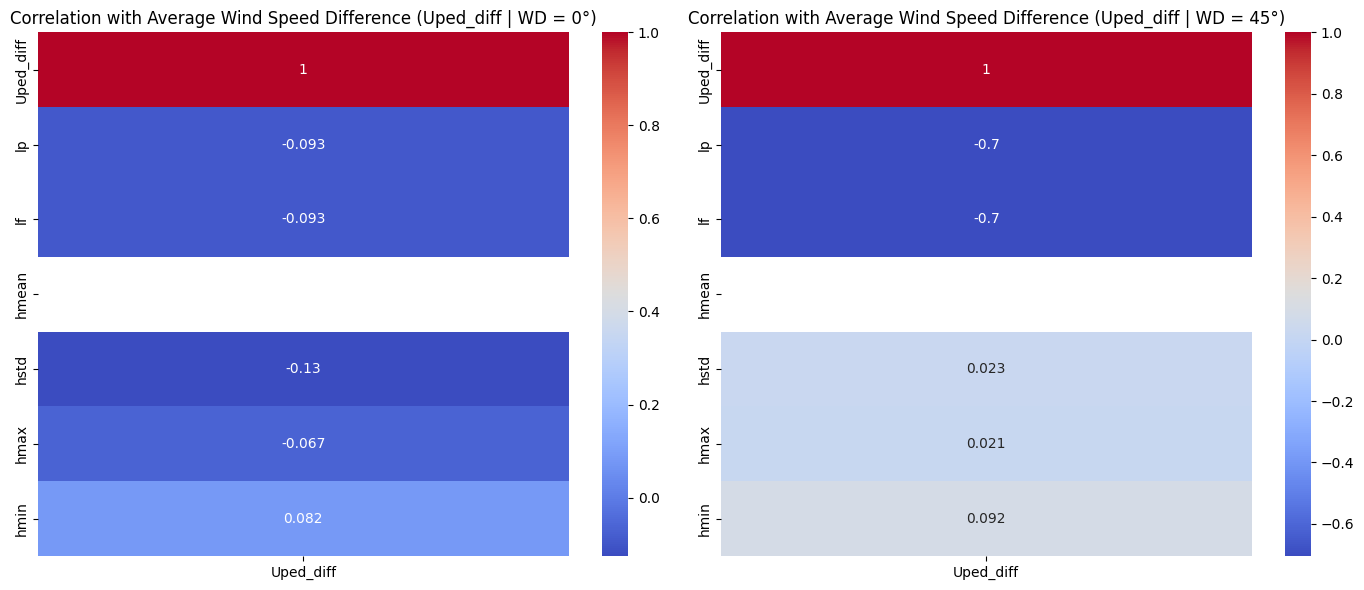

In [19]:
# Split the merged dataset into two separate dataframes based on the prevailing wind direction (WD=0 degrees and WD=45 degrees)
df_0 = merged_df[merged_df['WD'] == 0]
df_45 = merged_df[merged_df['WD'] == 45]

#Compute correlation matrices for each wind direction subset
#Includes correlation between Uped_diff (Average wind speed difference) and urban morphological paramters
corr_0 = df_0[['Uped_diff', 'lp', 'lf', 'hmean', 'hstd', 'hmax', 'hmin']].corr()
corr_45 = df_45[['Uped_diff', 'lp', 'lf', 'hmean', 'hstd', 'hmax', 'hmin']].corr()

#Importing visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

#Setting up a side-by-side layout for two heatmaps using Matplotlib
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#Plot heatmap for WD=0 degrees correlations with Uped_diff
#The heatmap is restricted to correlations between Uped_diff and each morphological feature
sns.heatmap(corr_0[['Uped_diff']], annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title("Correlation with Average Wind Speed Difference (Uped_diff | WD = 0°)")

#Similarly plotting the heatmap for WD=45 degrees and applying the same
sns.heatmap(corr_45[['Uped_diff']], annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title("Correlation with Average Wind Speed Difference (Uped_diff | WD = 45°)")

#Adjust the subplot layout to prevent overlapping elements
plt.tight_layout()

#Save the figure to a high-resolution PNG file for including in reports
plt.savefig("Correlation_with_Uped_diff.png", dpi=300, bbox_inches='tight')

#Displaying the resulting plots in the notebook output
plt.show()

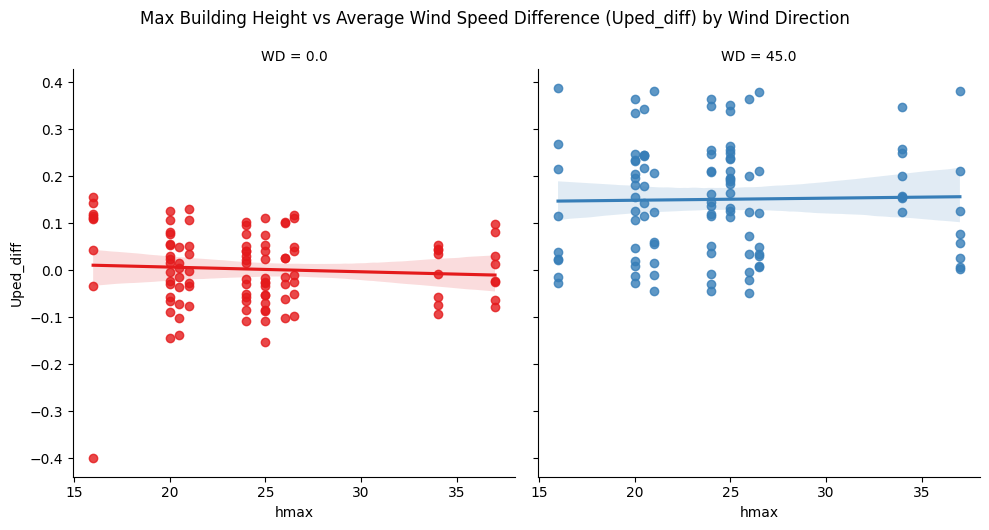

In [20]:
#Re-importing the visualization libraries to make the cell stand-alone
import seaborn as sns
import matplotlib.pyplot as plt

#Create a scatter plot with a linear regression fit line (using seaborn's lmplot)
#This plots the relationship between max building height (hmax) and average wind speed difference (Uped_diff)
#The data is faceted by wind direction (WD), producing one plot for each direction (0 and 45 degrees)
sns.lmplot(
    data=merged_df, # Data source
    x='hmax', # X-axis: maximum building height
    y='Uped_diff', # Y-axis: wind speed difference (windward - leeward)
    col='WD', # Create separate plots for each wind direction (WD = 0°, 45°)
    hue='WD', # Color the points by wind direction for visual distinction
    palette='Set1', # Use a predefined color palette
    height=5, # Height of each subplot (in inches)
    aspect=1 # Aspect ratio (width = height * aspect)
)

#Setting an overall title for the faceted plots, positioned slightly above the plots
plt.suptitle("Max Building Height vs Average Wind Speed Difference (Uped_diff) by Wind Direction", y=1.05)
#Save the generated figure to a high-resolution PNG file
plt.savefig("Max Building Height vs Wind Speed Difference by Wind Direction.png", dpi=300, bbox_inches='tight')
#Display the plot inline (in notebooks)
plt.show()

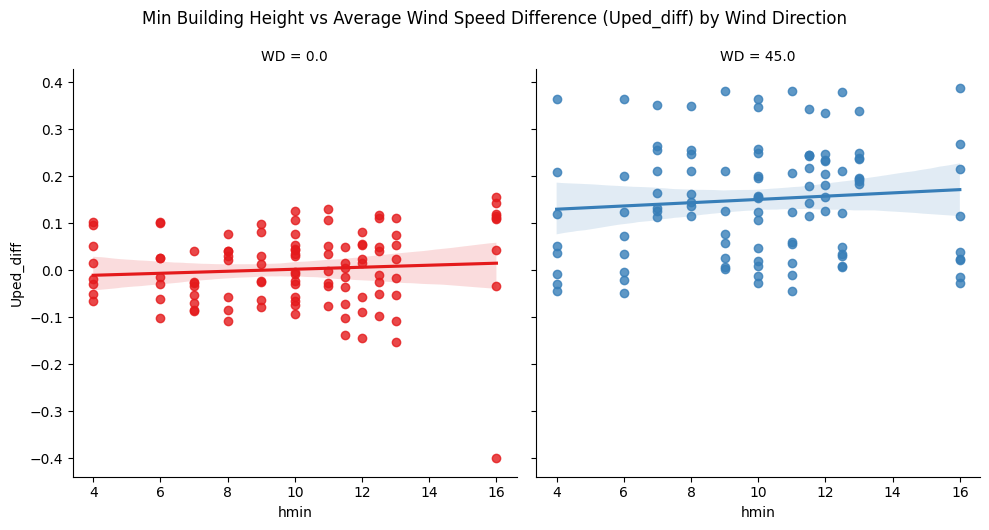

In [21]:
#Again, creating a scatter plot with a linear regression fit line (using seaborn's lmplot)
#This plots the relationship between min building height (hmin) and average wind speed difference (Uped_diff)
#The data is faceted by wind direction (WD), producing one plot for each direction (0 and 45 degrees)
sns.lmplot(
    data=merged_df, # Data source
    x='hmin', # X-axis: minimum building height
    y='Uped_diff', # Y-axis: wind speed difference (windward - leeward)
    col='WD', # Create separate plots for each wind direction (WD = 0°, 45°)
    hue='WD', # Color the points by wind direction for visual distinction
    palette='Set1', # Use a predefined color palette
    height=5, # Height of each subplot (in inches)
    aspect=1 # Aspect ratio (width = height * aspect)
)

#Setting an overall title for the faceted plots, positioned slightly above the plots
plt.suptitle("Min Building Height vs Average Wind Speed Difference (Uped_diff) by Wind Direction", y=1.05)
#Save the generated figure to a high-resolution PNG file
plt.savefig("Min Building Height vs Wind Speed Difference by Wind Direction.png", dpi=300, bbox_inches='tight')
#Display the plot inline (in notebooks)
plt.show()

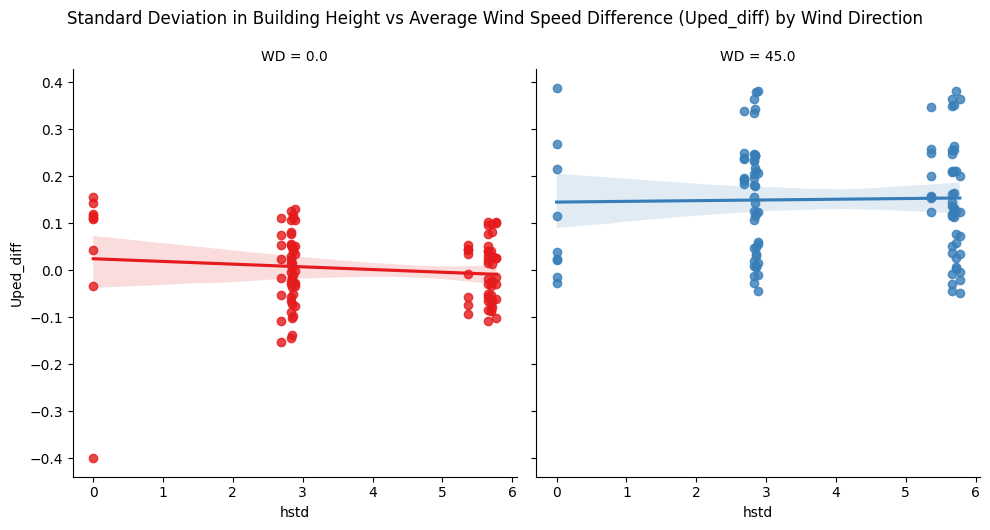

In [22]:
#Here we create a scatter plot with a linear regression fit line (using seaborn's lmplot)
#This plots the relationship between standard deviation in building height (hstd) and average wind speed difference (Uped_diff)
#The data is faceted by wind direction (WD), producing one plot for each direction (0 and 45 degrees)
sns.lmplot(
    data=merged_df, # Data source
    x='hstd', # X-axis: standard deviation in building height
    y='Uped_diff', # Y-axis: wind speed difference (windward - leeward)
    col='WD', # Create separate plots for each wind direction (WD = 0°, 45°)
    hue='WD', # Color the points by wind direction for visual distinction
    palette='Set1', # Use a predefined color palette
    height=5, # Height of each subplot (in inches)
    aspect=1 # Aspect ratio (width = height * aspect)
)

#Setting an overall title for the faceted plots, positioned slightly above the plots
plt.suptitle("Standard Deviation in Building Height vs Average Wind Speed Difference (Uped_diff) by Wind Direction", y=1.05)
#Save the generated figure to a high-resolution PNG file
plt.savefig("Standard Deviation in Building Height vs Wind Speed Difference by Wind Direction.png", dpi=300, bbox_inches='tight')
#Display the plot inline (in notebooks)
plt.show()

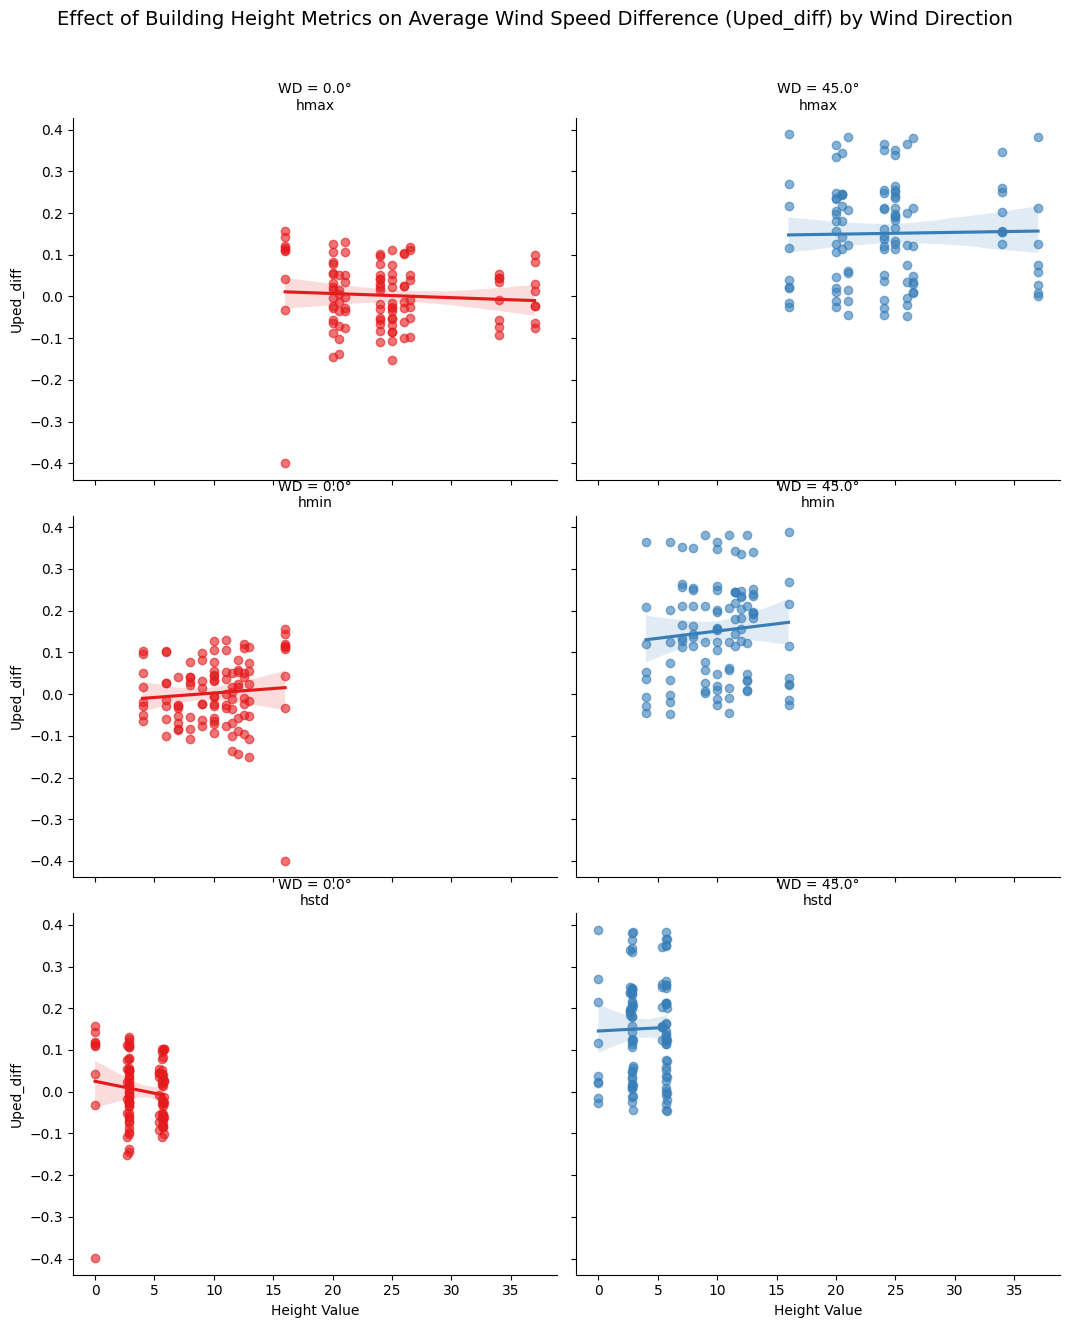

In [23]:
#Re-importing necessary libraries to make the cell standalone
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

#Step 1: Reshape the Dataframe from wide to long format
#This is necessary for plotting multiple height metrics (hmax,hmin,hstd) on the same axis
long_df = merged_df.melt(
    id_vars=['WD', 'Uped_diff'], # Keep wind direction and wind speed difference as identifier variables
    value_vars=['hmax', 'hmin', 'hstd'], # Height-related columns to unpivot
    var_name='Height Metric', # New column name for the type of height metric
    value_name='Height Value' # New column name for the value of each height metric
)

#Step2: Create a faceted linear regression plot using seaborn's lmplot
#Each row represents a height metric, and each column represents a wind direction
g = sns.lmplot(
    data=long_df, # Long-format DataFrame for plotting
    x='Height Value', # X-axis: numerical value of the height metric
    y='Uped_diff', # Y-axis: wind speed difference between windward and leeward sides
    col='WD', # Facet by wind direction across columns (0° and 45°)
    row='Height Metric', # Facet by height metric across rows (hmax, hmin, hstd)
    hue='WD', # Color code by wind direction
    palette='Set1', # Use a consistent color palette
    height=4.5, # Height of each subplot (in inches)
    aspect=1.2,  # Aspect ratio (width = height × aspect)
    scatter_kws={'alpha': 0.6} # Set transparency of scatter points for readability
)

#Step 3: Customize subplot titles and add an overall figure title
g.set_titles("WD = {col_name}°\n{row_name}")  # Format subplot titles to show both WD and metric
g.fig.subplots_adjust(top=0.9) # Adjust layout to make space for a super title
g.fig.suptitle("Effect of Building Height Metrics on Average Wind Speed Difference (Uped_diff) by Wind Direction", fontsize=14)

#Save the complete figure to file in high resolution
plt.savefig("Effect of Building Height Metrics on Wind Speed Difference by Wind Direction.png", dpi=300, bbox_inches='tight')
#Show the plot in notebook output
plt.show()

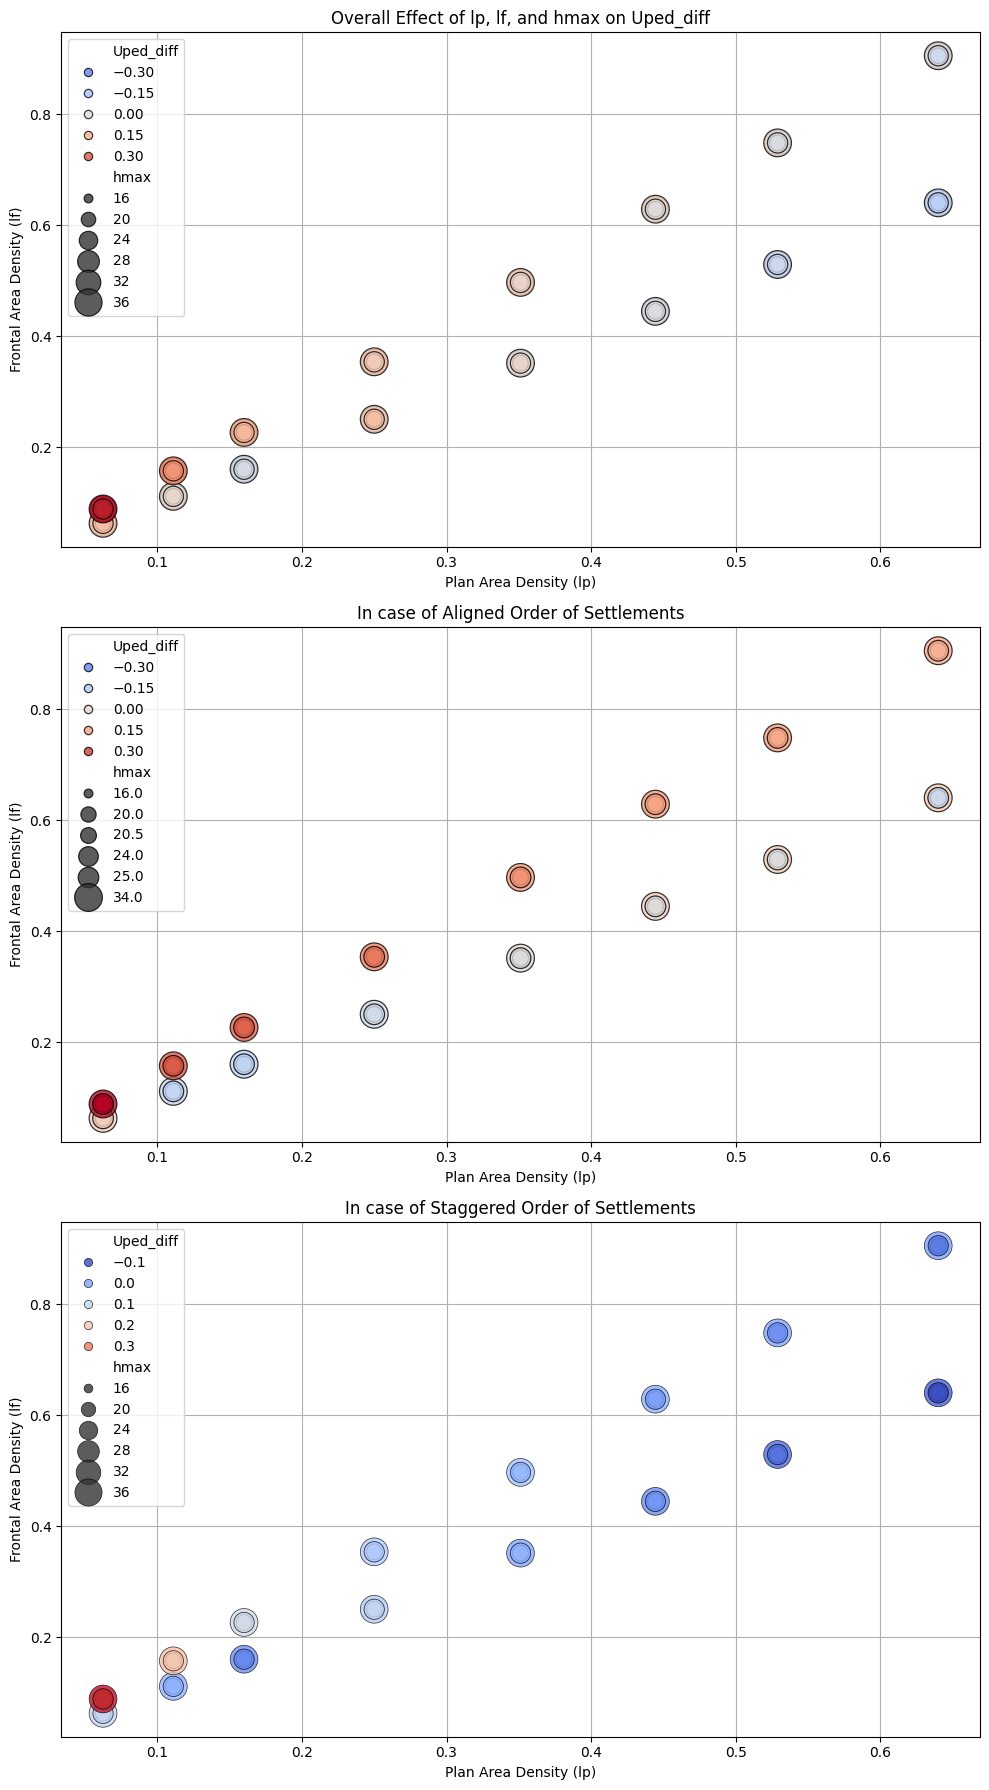

In [24]:
# Re-importing the libraries for making the cell standalone
import matplotlib.pyplot as plt  # For creating plots and visualizations
import seaborn as sns  # For statistical data visualization (built on top of matplotlib)

# Splitting the main dataframe into two separate dataframes based on the 'SARS' column
# 'A' stands for 'Aligned' and 'S' stands for 'Staggered' settlement patterns
aligned_df = merged_df[merged_df['SAR'] == 'A']  # Filter rows where SARS is 'A' (Aligned)
staggered_df = merged_df[merged_df['SAR'] == 'S']  # Filter rows where SARS is 'S' (Staggered)

# Creating a figure with 3 vertically stacked subplots
# figsize sets the width to 10 inches and height to 18 inches
fig, axes = plt.subplots(3, 1, figsize=(10, 18))  # 3 rows, 1 column of plots

# --- First Plot: Overall Dataset ---

# Creating a scatter plot for the entire dataset
sns.scatterplot(
    data=merged_df,        # Full dataset used for plotting
    x='lp', y='lf',        # X-axis is 'lp' (Plan area density), Y-axis is 'lf' (Frontal area density)
    size='hmax',           # Size of each point is based on 'hmax' (maximum building height)
    hue='Uped_diff',       # Color of each point represents 'Uped_diff' (wind speed difference)
    palette='coolwarm',    # Color palette from cool (low) to warm (high)
    sizes=(40, 400),       # Range of point sizes: smallest = 40, largest = 400
    alpha=0.8,             # Set point transparency to 80% for better visibility
    edgecolor='k',         # Add a black edge to each point for contrast
    ax=axes[0]             # Plot on the first subplot (top of the figure)
)
axes[0].set_title("Overall Effect of lp, lf, and hmax on Uped_diff")  # Title for the first plot
axes[0].set_xlabel("Plan Area Density (lp)")  # X-axis label
axes[0].set_ylabel("Frontal Area Density (lf)")  # Y-axis label
axes[0].grid(True)  # Show grid lines for easier reading of values

# --- Second Plot: Aligned Settlements Only ---

# Creating a scatter plot for only aligned settlements
sns.scatterplot(
    data=aligned_df,       # Only rows where SARS == 'A'
    x='lp', y='lf',        # Same axes as before
    size='hmax',           # Point size still based on building height
    hue='Uped_diff',       # Color still based on wind speed difference
    palette='coolwarm',    # Same color palette for consistency
    sizes=(40, 400),       # Same point size range
    alpha=0.8,             # Same transparency
    edgecolor='k',         # Same edge color
    ax=axes[1]             # Plot on the second subplot (middle of the figure)
)
axes[1].set_title("In case of Aligned Order of Settlements")  # Title for the second plot
axes[1].set_xlabel("Plan Area Density (lp)")  # X-axis label
axes[1].set_ylabel("Frontal Area Density (lf)")  # Y-axis label
axes[1].grid(True)  # Show grid lines

# --- Third Plot: Staggered Settlements Only ---

# Creating a scatter plot for only staggered settlements
sns.scatterplot(
    data=staggered_df,     # Only rows where SARS == 'S'
    x='lp', y='lf',        # Same axes
    size='hmax',           # Same point sizing
    hue='Uped_diff',       # Same color mapping
    palette='coolwarm',    # Same palette for uniform appearance
    sizes=(40, 400),       # Same point size range
    alpha=0.8,             # Same transparency
    edgecolor='k',         # Black edges for consistency
    ax=axes[2]             # Plot on the third subplot (bottom of the figure)
)
axes[2].set_title("In case of Staggered Order of Settlements")  # Title for the third plot
axes[2].set_xlabel("Plan Area Density (lp)")  # X-axis label
axes[2].set_ylabel("Frontal Area Density (lf)")  # Y-axis label
axes[2].grid(True)  # Enable grid

# Adjust the layout to prevent overlapping labels and titles
plt.tight_layout()

# Save the final figure as a high-resolution PNG file
# 'dpi=300' means 300 dots per inch (print quality)
# 'bbox_inches=tight' trims unnecessary white space around the figure
plt.savefig("Effect_of_lp_lf_hmax_on_Wind_Speed_Difference_vertical.png", dpi=300, bbox_inches='tight')

# Display the plot inline (useful for Jupyter Notebooks)
plt.show()


In [25]:
#Display summary statistics for the columns 'hmin' and 'hmax' in the merged Dataframe.
print(merged_df[['hmin', 'hmax']].describe())
#It helps in understanding the distribution and range of building heights. This includes checking validity and outliers as well.

             hmin        hmax
count  210.000000  210.000000
mean    10.057143   24.457143
std      3.142024    5.559644
min      4.000000   16.000000
25%      8.000000   20.500000
50%     10.000000   24.000000
75%     12.000000   26.000000
max     16.000000   37.000000


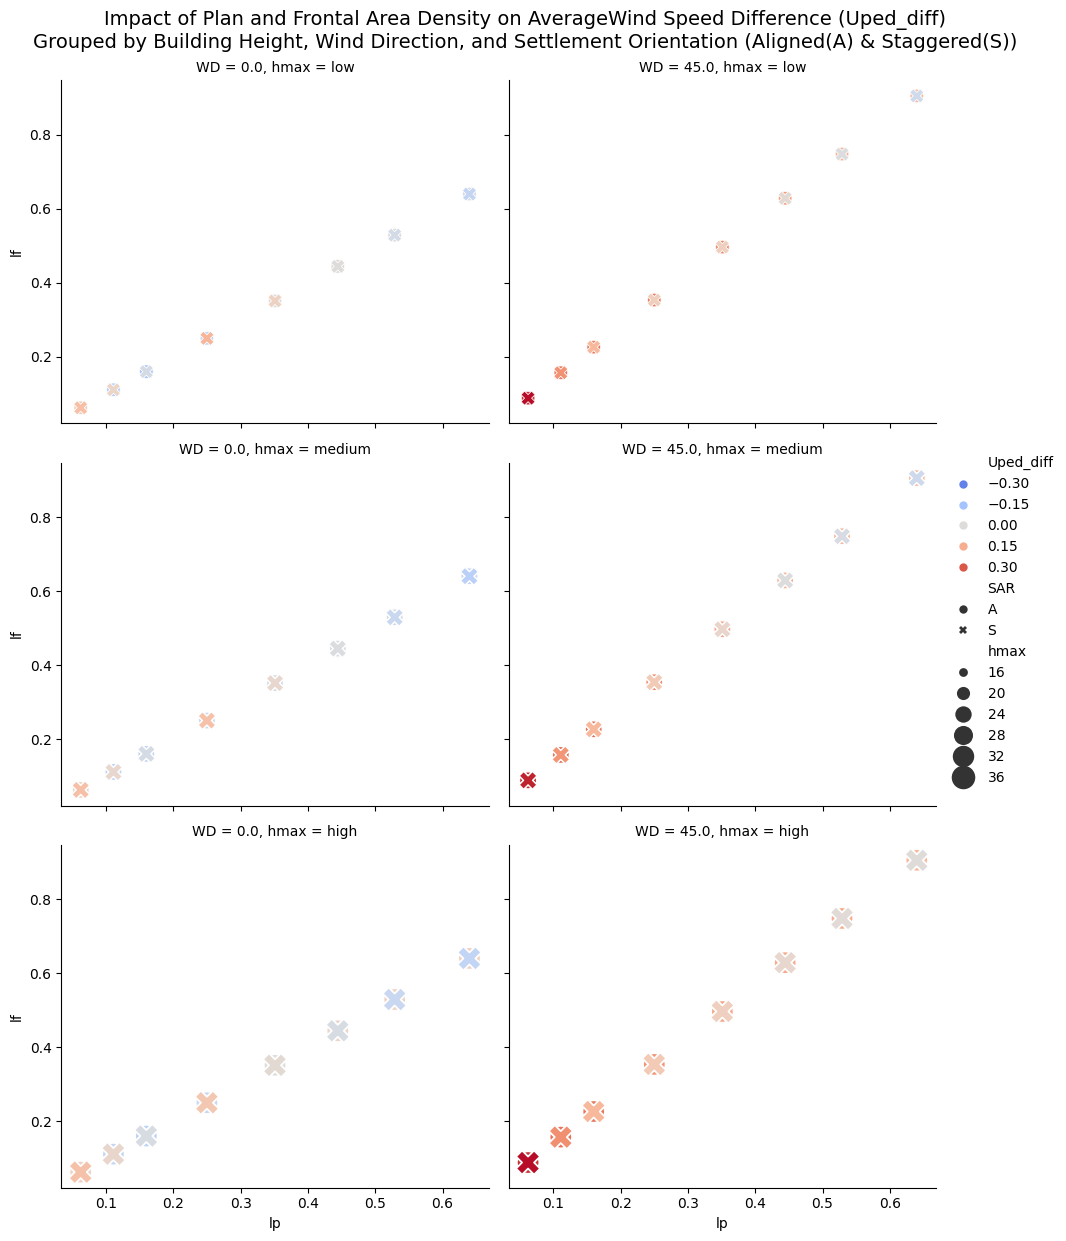

In [26]:
# Bin 'hmax' into three categories: low, medium, high
# The bin edges were chosen based on summary statistics from describe()
merged_df['hmax_group'] = pd.cut(
    merged_df['hmax'],               # Column to bin
    bins=[15, 22, 28, 38],           # Ranges for binning
    labels=['low', 'medium', 'high'],# Corresponding bin labels
    include_lowest=True              # Include the lowest value (15) in the first bin
)

# Create a faceted scatter plot using seaborn's relplot
# This will create a grid of plots: columns by wind direction (WD), rows by hmax_group
# We add 'style=SAR' to distinguish Aligned vs Staggered using different point shapes
g = sns.relplot(
    data=merged_df,       # Data source
    x='lp', y='lf',       # X and Y axes: Plan area density and Frontal area density
    hue='Uped_diff',      # Color represents wind speed difference
    size='hmax',          # Point size by building height
    style='SAR',         # Marker shape by settlement orientation ('A' or 'S')
    col='WD',             # Columns: wind direction (e.g., 0, 45 degrees)
    row='hmax_group',     # Rows: height group (low, medium, high)
    palette='coolwarm',   # Color palette for Uped_diff
    sizes=(40, 300),      # Point size range
    height=4, aspect=1.2  # Size and aspect ratio of each subplot
)

# Set dynamic titles for each subplot using column and row names
g.set_titles("WD = {col_name}, hmax = {row_name}")

# Set a main title for the entire figure
plt.suptitle(
    "Impact of Plan and Frontal Area Density on AverageWind Speed Difference (Uped_diff)\n"
    "Grouped by Building Height, Wind Direction, and Settlement Orientation (Aligned(A) & Staggered(S))",
    y=1.03, fontsize=14
)

# Save the complete plot grid as a high-resolution image
plt.savefig("Plan_vs_Frontal_Density_by_WD_Height_SAR.png", dpi=300, bbox_inches='tight')

# Display the plot
plt.show()


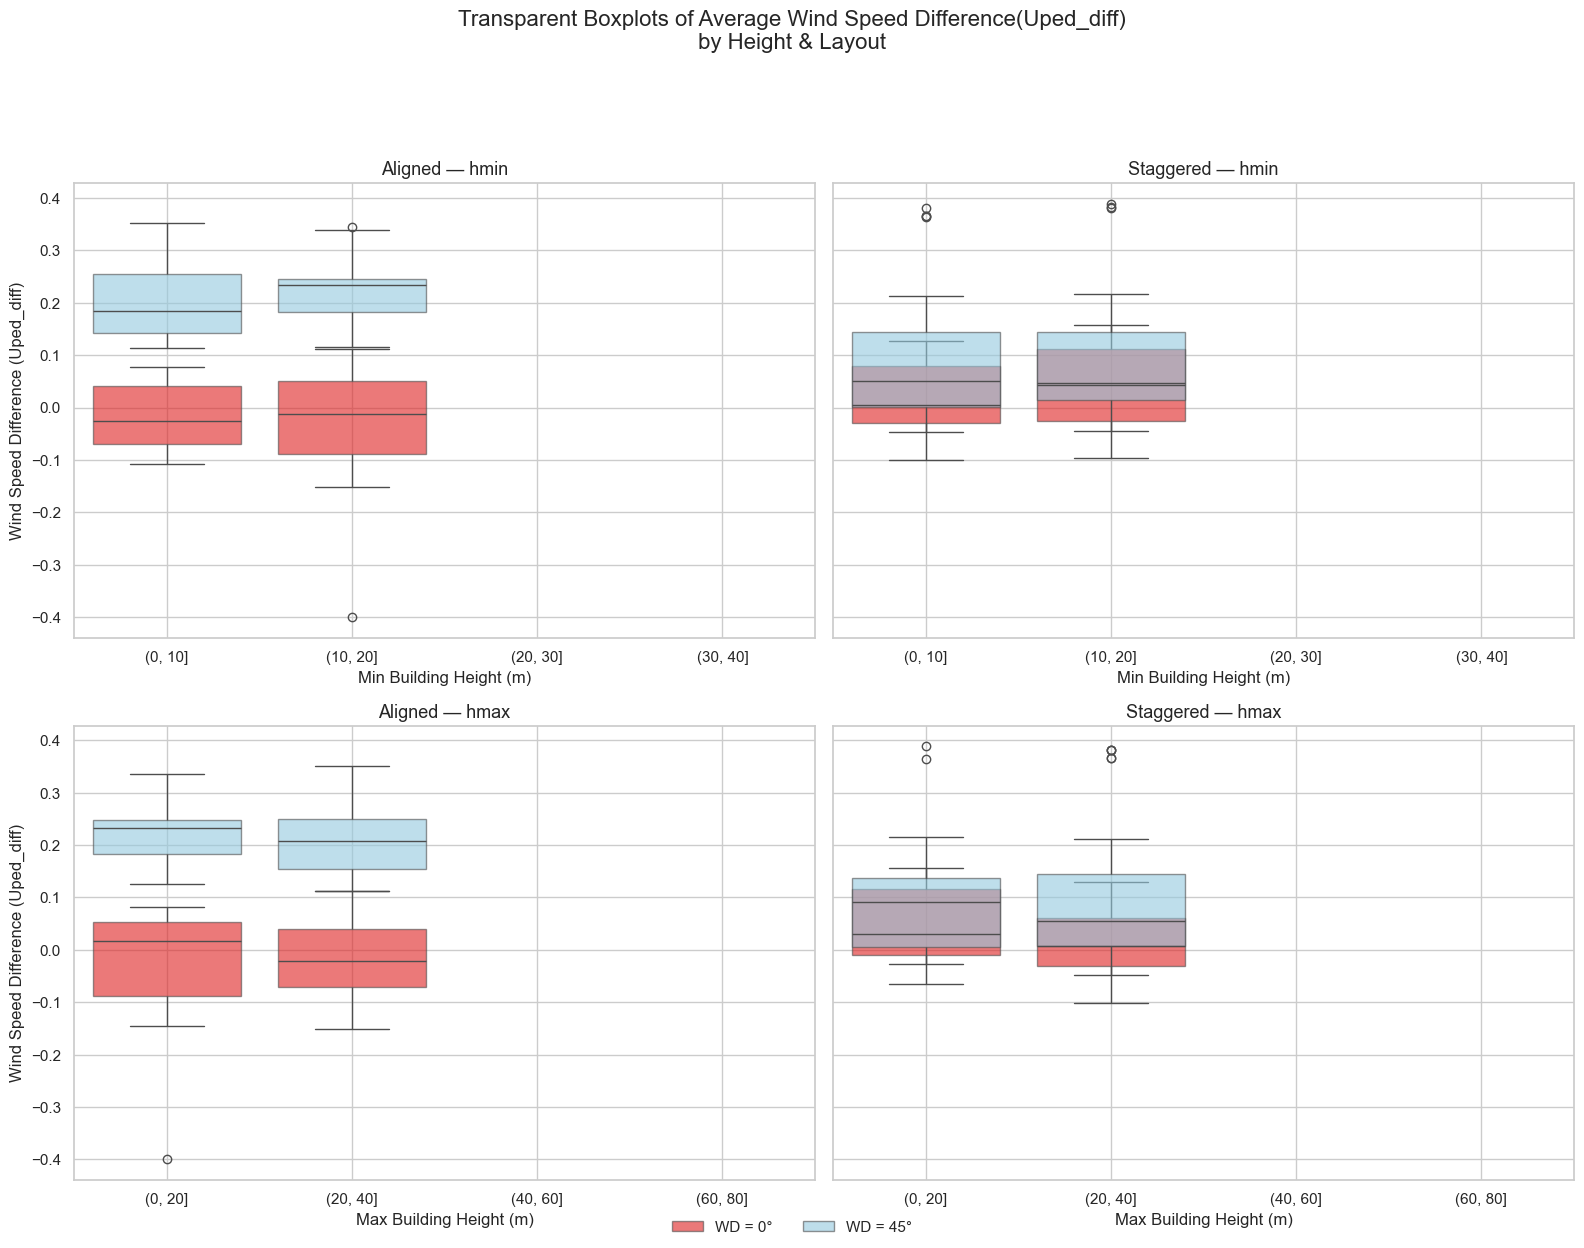

In [27]:
# Categorize hmin into Low, Medium, High
merged_df['hmin_cat'] = pd.cut(merged_df['hmin'], bins=[0, 10, 20, 30], labels=['Low', 'Medium', 'High'])

# Categorize hmax into Low, Medium, High
merged_df['hmax_cat'] = pd.cut(merged_df['hmax'], bins=[0, 20, 40, 60], labels=['Low', 'Medium', 'High'])

# Filter only Staggered ('S') and Aligned ('A') street layout configurations
df_config = merged_df[merged_df['SAR'].isin(['A', 'S'])].copy()

# Set style
sns.set(style="whitegrid")

# Define new bins for detailed analysis
hmin_bins = [0, 10, 20, 30, 40]
hmax_bins = [0, 20, 40, 60, 80]
# Bin the hmin and hmax data accordingly
merged_df['hmin_bin'] = pd.cut(merged_df['hmin'], bins=hmin_bins)
merged_df['hmax_bin'] = pd.cut(merged_df['hmax'], bins=hmax_bins)

# Re-filter only staggered and aligned cases (re-doing for safety after binning)
df_config = merged_df[merged_df['SAR'].isin(['A', 'S'])].copy()

# Color palette for different wind directions
palette_dict = {0: 'red', 45: 'skyblue'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)

# Plotting function with post-process alpha
def transparent_boxplot(data, x, y, hue, ax, title, xlabel, show_ylabel=False):
    box = sns.boxplot(data=data, x=x, y=y, hue=hue, palette=palette_dict, ax=ax)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(xlabel)
    if show_ylabel:
        ax.set_ylabel("Wind Speed Difference (Uped_diff)")
    else:
        ax.set_ylabel("")
    ax.grid(True)

    # Make the boxes slightly transparent
    for patch in ax.patches:
        patch.set_alpha(0.6)

    ax.legend_.remove()

# Top: hmin
transparent_boxplot(
    df_config[df_config['SAR'] == 'A'], 'hmin_bin', 'Uped_diff', 'WD',
    axes[0, 0], 'Aligned — hmin', "Min Building Height (m)", show_ylabel=True
)

transparent_boxplot(
    df_config[df_config['SAR'] == 'S'], 'hmin_bin', 'Uped_diff', 'WD',
    axes[0, 1], 'Staggered — hmin', "Min Building Height (m)", show_ylabel=False
)

# Bottom: hmax
transparent_boxplot(
    df_config[df_config['SAR'] == 'A'], 'hmax_bin', 'Uped_diff', 'WD',
    axes[1, 0], 'Aligned — hmax', "Max Building Height (m)", show_ylabel=True
)

transparent_boxplot(
    df_config[df_config['SAR'] == 'S'], 'hmax_bin', 'Uped_diff', 'WD',
    axes[1, 1], 'Staggered — hmax', "Max Building Height (m)", show_ylabel=False
)

# Extract handles for custom legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, ['WD = 0°', 'WD = 45°'], loc='lower center', ncol=2, frameon=False)

# Set main title and layout
plt.suptitle("Transparent Boxplots of Average Wind Speed Difference(Uped_diff)\nby Height & Layout", fontsize=16, y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("Transparent Boxplots of Wind Speed Difference by Height & Layout.png", dpi=300, bbox_inches='tight')
plt.show()


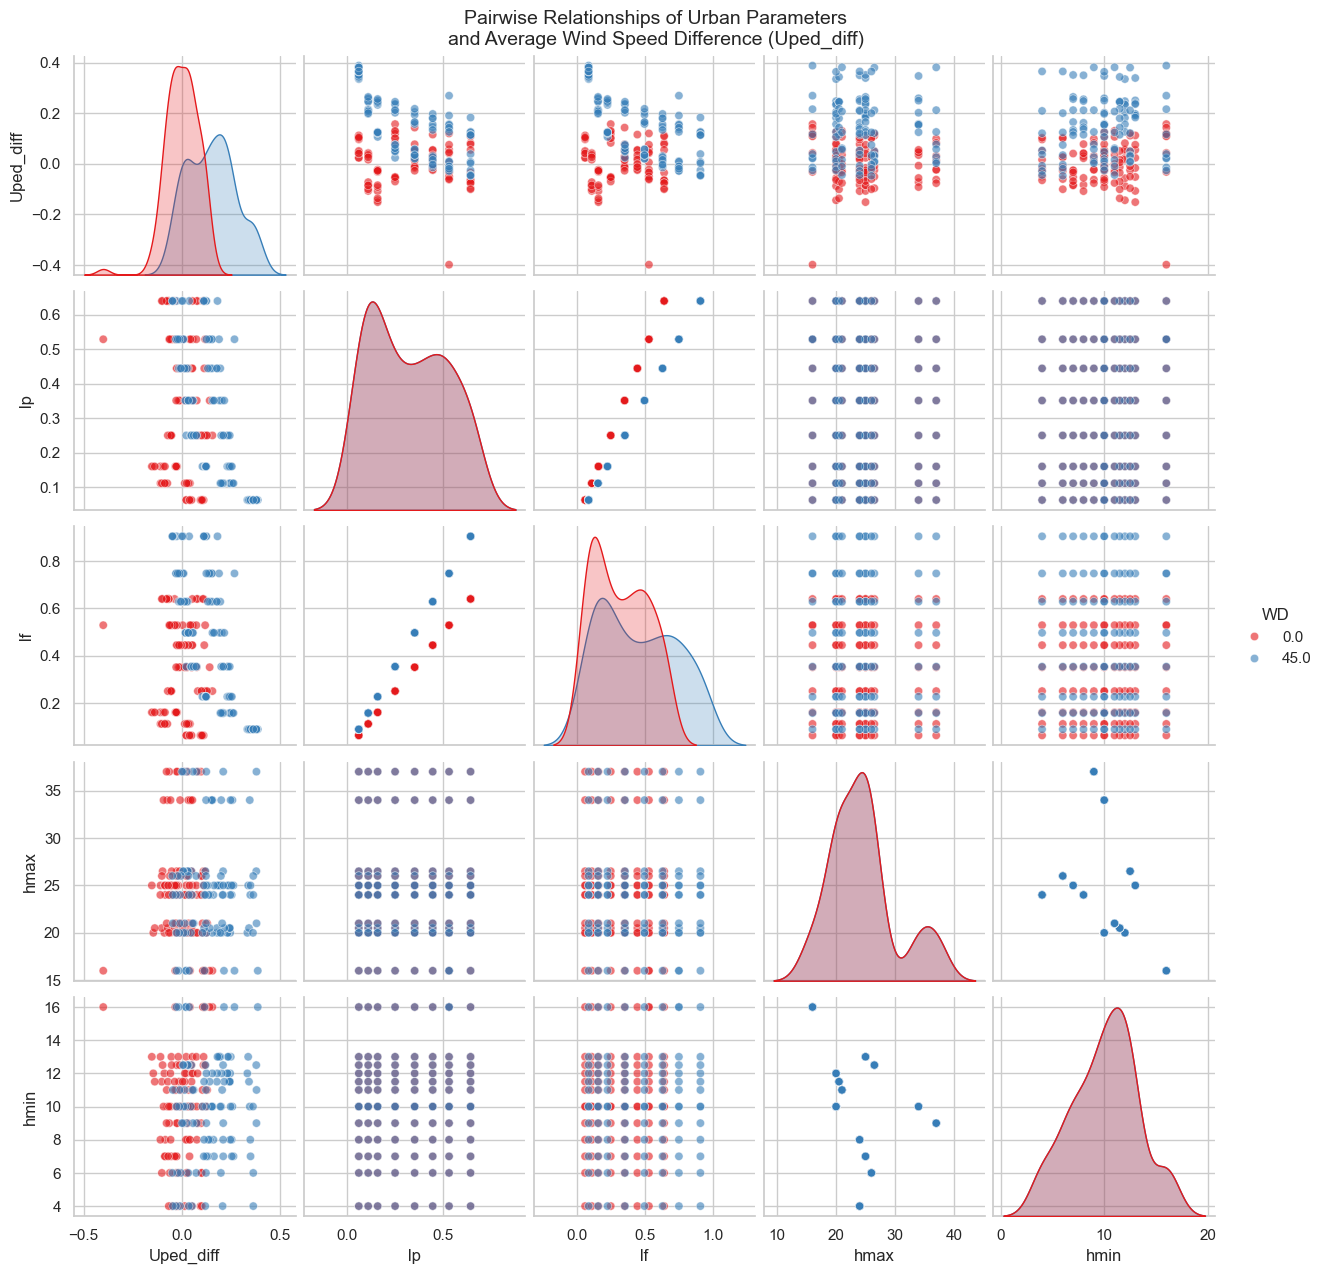

In [28]:
# Create the pairplot
g = sns.pairplot(
    data=merged_df,
    vars=['Uped_diff', 'lp', 'lf', 'hmax', 'hmin'],
    hue='WD',
    palette='Set1',
    plot_kws={'alpha': 0.6}  # <-- This applies transparency to scatter plots
)

# Set multi-line title
g.fig.suptitle("Pairwise Relationships of Urban Parameters\nand Average Wind Speed Difference (Uped_diff)", y=1.02, fontsize=14)
plt.savefig("Pairwise Relationships of Urban Parameters and Wind Speed Difference.png", dpi=300, bbox_inches='tight')
plt.show()